In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
# Charger le dataset
data = pd.read_csv('air_quality_dataset.csv')

# Afficher les premières lignes pour vérifier
print(data.head())

    CO2 (ppm)  Température (°C)  Humidité (%)  Qualité de l'air
0  965.547478         20.292266     47.842436                 0
1  784.398583         10.788655     65.932999                 0
2  365.589441         32.801652     31.419878                 0
3  651.499275         27.235297     71.565684                 0
4  784.575750         13.510292     36.377293                 0


In [20]:
X = data[['CO2 (ppm)', 'Température (°C)', 'Humidité (%)']]


Matrice de corrélation :
                  CO2 (ppm)  Température (°C)  Humidité (%)  Qualité de l'air
CO2 (ppm)          1.000000         -0.045717     -0.025755         -0.590008
Température (°C)  -0.045717          1.000000     -0.060759         -0.166922
Humidité (%)      -0.025755         -0.060759      1.000000         -0.240059
Qualité de l'air  -0.590008         -0.166922     -0.240059          1.000000


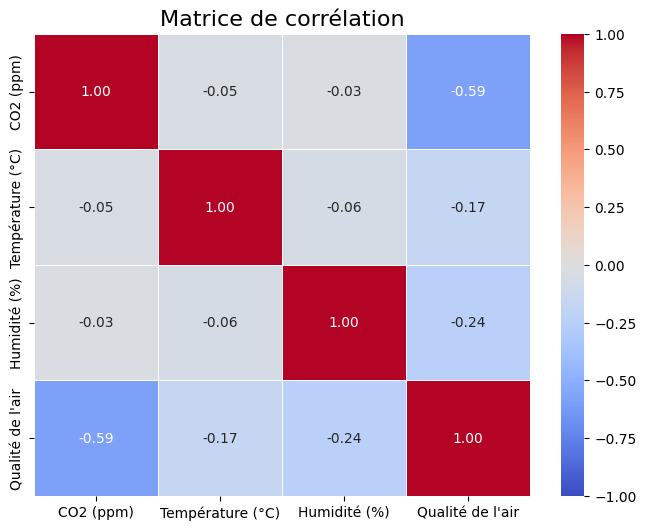

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculer la matrice de corrélation
correlation_matrix = data.corr()

# Afficher la matrice de corrélation
print("Matrice de corrélation :")
print(correlation_matrix)

# Créer une heatmap pour visualiser la matrice de corrélation
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Afficher les valeurs dans les cellules
    cmap="coolwarm",     # Palette de couleurs
    vmin=-1,             # Valeur minimale de la corrélation
    vmax=1,              # Valeur maximale de la corrélation
    linewidths=0.5,      # Largeur des lignes entre les cellules
    fmt=".2f"            # Format des annotations (2 décimales)
)

# Ajouter un titre
plt.title("Matrice de corrélation", fontsize=16)

# Afficher la heatmap
plt.show()

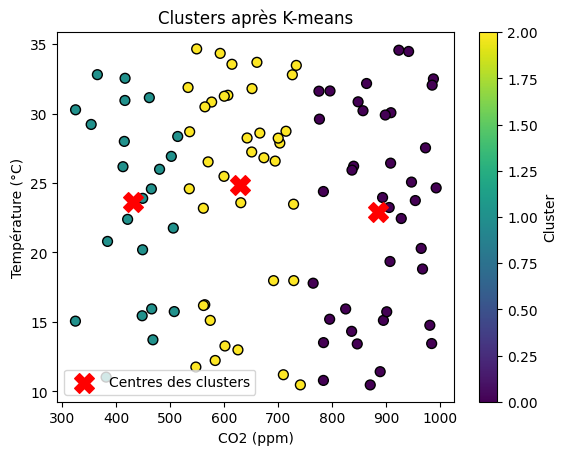

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Créer et entraîner le modèle K-means
model = KMeans(n_clusters=3)  # Choisissez le nombre de clusters approprié
model.fit(X)

# Prédire les clusters pour les données
y_labels = model.predict(X)

# Tracer les clusters
plt.scatter(X['CO2 (ppm)'], X['Température (°C)'], c=y_labels, cmap='viridis', marker='o', edgecolor='k', s=50)
plt.title('Clusters après elBow')
plt.xlabel('CO2 (ppm)')
plt.ylabel('Température (°C)')
plt.colorbar(label='Cluster')

# Tracer les centres des clusters en rouge
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centres des clusters')
plt.legend()
plt.show()

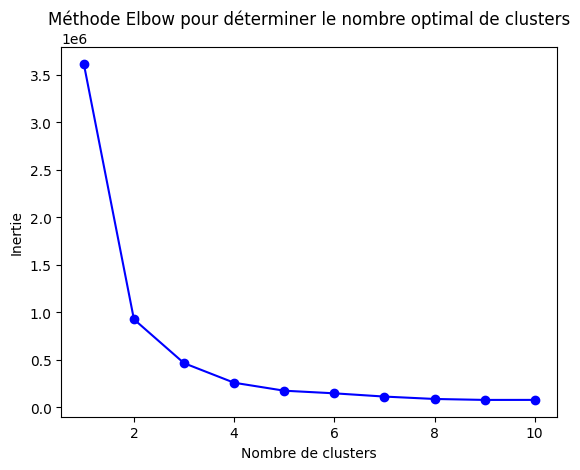

In [23]:
inertia = []
K_range = range(1, 11)  # Testez de 1 à 10 clusters
for k in K_range:
    model = KMeans(n_clusters=k).fit(X)
    inertia.append(model.inertia_)

# Tracer la courbe Elbow
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode Elbow pour déterminer le nombre optimal de clusters')
plt.show()

In [24]:
# Calculer l'inertie
inertia = model.inertia_
print(f"Inertie : {inertia}")


Inertie : 78493.56194209568
